# 🧠 Modelo 5: Transfer Learning Avanzado con ResNet50

En este notebook utilizamos la arquitectura **ResNet50** (una de las más potentes en visión por computador) preentrenada en ImageNet. Aplicamos **Learning Rate Scheduling** y evaluamos su desempeño con métricas especializadas (AUC).

---

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_resnet50_unfrozen as resnet_model

print("✅ Librerías e importaciones listas")

c:\Users\pablo\miniconda3\envs\oct_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librerías e importaciones listas


In [2]:
# Configurar GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {(gpu)}")
    except RuntimeError as e:
        print(e)
else:
    print(" No se detectó GPU. Se usará la CPU.")

GPU detectada(s): PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 1. Carga de Datos (RGB para ResNet50)

**IMPORTANTE**: ResNet50 está diseñado para imágenes en color (3 canales). Por ello, configuramos `color_mode='rgb'` en el dataloader.

In [3]:
# Descargar/Localizar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

# Configuración del DataLoader
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SUBSET = 0.8 # Usamos el 30% del entrenamiento para que sea fluido

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb', # <--- OBLIGATORIO para ResNet50
    train_subset_fraction=SUBSET, 
    optimize=False
)

⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (224, 224)
   • Batch size: 16
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 80.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
   ⚠️  Usando 80.0% del dataset de entrenamiento
   ⚠️  Batches: 3826 de 4783
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      3826 batches
Validation: 1367 batches
Test:       684 batches



## 2. Creación y Compilación del Modelo

ResNet50 tiene millones de parámetros. Congelamos su base para realizar solo **Transfer Learning** sobre las capas superiores que hemos añadido.

In [ ]:
from tensorflow.keras.metrics import AUC

# Hiperparámetros configurables
LEARNING_RATE = 3e-5
DROPOUT = 0.4

# 1. Crear el modelo con ResNet50
model = resnet_model.create_resnet_model(
    input_shape=(224, 224, 3), # (Ancho, Alto, Canales RGB)
    num_classes=4, 
    dropout_rate=DROPOUT
)

# 2. Compilar especificando métricas (incluyendo el AUC para mayor robustez)
metrics = [
    'accuracy'
]

model = resnet_model.compile_resnet_model(
    model, 
    learning_rate=LEARNING_RATE, 
    metrics=metrics
)

model.summary()

Model: "ResNet50_Transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 256)               0         
                                                                 
 dropout (Dropout)           (None, 256)         

## 3. Entrenamiento con Scheduler

Implementamos `ReduceLROnPlateau` para mejorar la estabilidad del entrenamiento.

In [5]:
EPOCHS = 100

# Obtener callbacks avanzados
callbacks = resnet_model.get_resnet_callbacks(
    patience_stop=5, 
    patience_lr=2, 
    factor_lr=0.2
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
3826/3826 [==============================] - ETA: 0s - loss: 0.2999 - accuracy: 0.9041
Epoch 1: val_loss improved from inf to 0.35582, saving model to modelos\best_resnet50.h5
3826/3826 [==============================] - 698s 180ms/step - loss: 0.2999 - accuracy: 0.9041 - val_loss: 0.3558 - val_accuracy: 0.8943 - lr: 0.0010
Epoch 2/100
3826/3826 [==============================] - ETA: 0s - loss: 0.1869 - accuracy: 0.9417
Epoch 2: val_loss did not improve from 0.35582
3826/3826 [==============================] - 663s 173ms/step - loss: 0.1869 - accuracy: 0.9417 - val_loss: 1.0244 - val_accuracy: 0.8848 - lr: 0.0010
Epoch 3/100
3826/3826 [==============================] - ETA: 0s - loss: 0.1523 - accuracy: 0.9508
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_loss did not improve from 0.35582
3826/3826 [==============================] - 660s 173ms/step - loss: 0.1523 - accuracy: 0.9508 - val_loss: 0.8923 - val_accuracy: 0.8979 - lr:

KeyboardInterrupt: 

## 4. Curvas de Aprendizaje y Evaluación

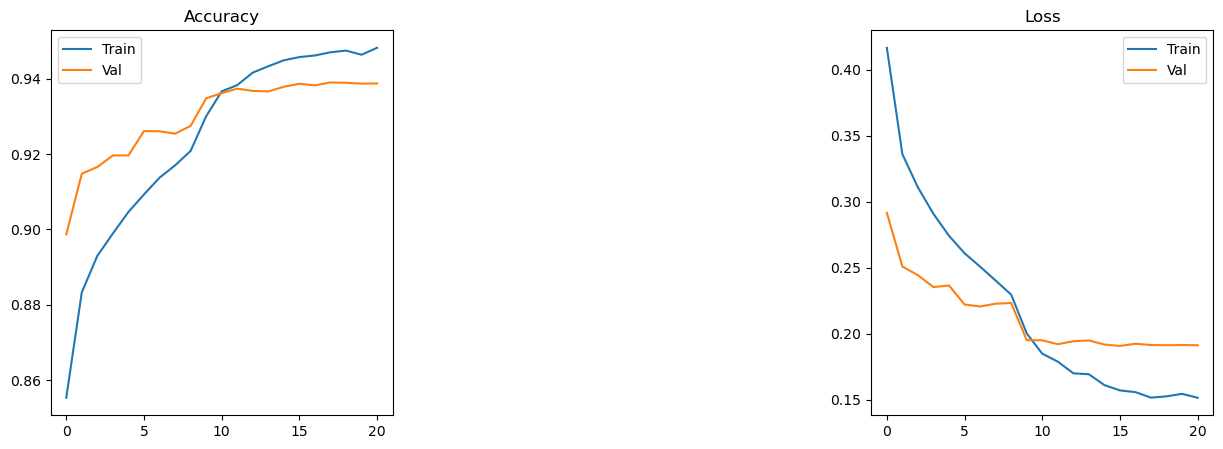

In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()



plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()

Loss en test: 0.2030
Accuracy en test: 0.9341

AUC por clase (One-vs-Rest):
 - CNV: 0.9950
 - DME: 0.9895
 - DRUSEN: 0.9591
 - NORMAL: 0.9931

AUC Promedio (Macro): 0.9842

Reporte de clasificacion:
              precision    recall  f1-score   support

         CNV       0.95      0.96      0.95      3746
         DME       0.92      0.86      0.89      1161
      DRUSEN       0.80      0.61      0.69       887
      NORMAL       0.95      0.99      0.96      5139

    accuracy                           0.93     10933
   macro avg       0.90      0.86      0.88     10933
weighted avg       0.93      0.93      0.93     10933



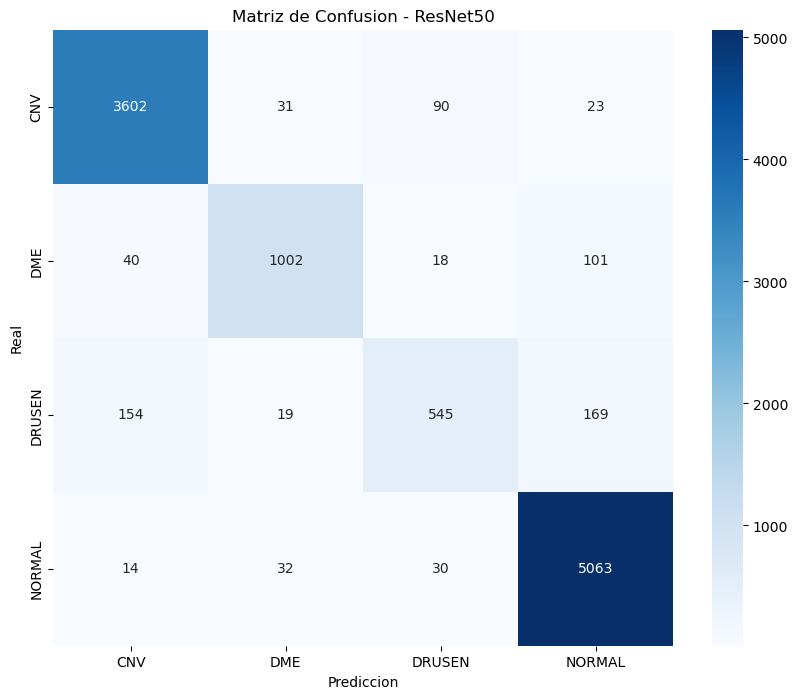

In [9]:
# --- Chunk: Evaluacion de Metricas Finales ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

results = model.evaluate(test_ds, verbose=0)
print(f"Loss en test: {results[0]:.4f}")
print(f"Accuracy en test: {results[1]:.4f}")

y_true = []
y_probs = []

# Obtencion de predicciones
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

# Calculo de AUC por clase
y_true_oh = to_categorical(y_true, num_classes=len(class_names))
print("\nAUC por clase (One-vs-Rest):")
auc_scores = []
for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_true_oh[:, i], y_probs[:, i])
    auc_scores.append(auc)
    print(f" - {class_name}: {auc:.4f}")

print(f"\nAUC Promedio (Macro): {np.mean(auc_scores):.4f}")

# Reporte de Clasificacion
print("\nReporte de clasificacion:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - ResNet50')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()
